![image.png](https://i.imgur.com/a3uAqnb.png)



# 🖼️ CLIP-Powered Image Search
## Text → Image & Image → Image Retrieval with OpenAI CLIP

This notebook builds an **image search engine** on top of the Flickr8k dataset
using **CLIP (Contrastive Language–Image Pre-training)**. Instead of training
anything from scratch, we lean on CLIP's pretrained joint vision-language
embedding space — every image and every text query lands in the same vector
space, so retrieval becomes a simple cosine-similarity lookup.

### **📌 What we'll cover**

1. **CLIP basics** — a shared embedding space for images *and* text
2. **Dataset loading** — pull Flickr8k from Kaggle and scan it for images
3. **Model setup** — load `openai/clip-vit-base-patch32` from HuggingFace
4. **Image encoding** — batch-process every image into a normalized embedding
5. **Text-to-image search** — turn a natural-language query into a ranked list of images
6. **Visualization helpers** — clean side-by-side panels of query + top-k results

### **🎯 Dataset: `adityajn105/flickr8k`**

A classic image-captioning dataset hosted on Kaggle, containing roughly 8k
everyday Flickr photos. We only need the images themselves — the captions are
ignored because CLIP supplies its *own* text understanding.

### **🧠 Why CLIP?**

CLIP was pretrained on hundreds of millions of (image, caption) pairs from the
web with a contrastive objective: matching pairs are pulled together in
embedding space, mismatched pairs are pushed apart. The result is a model that
can take an arbitrary text prompt and rank images by how well they match —
**zero training, zero fine-tuning required on our end**.

## ⚙️ Installation & Imports

We install the three external packages we need and then import the standard
PyTorch + utilities stack.

### **📦 Key dependencies**

- **`transformers`** — HuggingFace's library; gives us `CLIPModel` & `CLIPProcessor`
- **`kagglehub`** — one-line dataset downloader for Kaggle datasets
- **`umap-learn`** — dimensionality reduction (handy for later embedding visualization)


In [1]:
!pip install transformers kagglehub umap-learn -q

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from glob import glob
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor
import kagglehub

## 🔧 Configuration


In [3]:
TOP_K = 5
MODEL_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 64

## 🎨 Visualization Helpers

Two small plotting functions for displaying retrieval results. Both lay out the
query on the left and the top-k matches to its right, each labeled with its
cosine-similarity score.

### **🖼️ The two helpers**

1. **`show_results`** — for **text → image** search. The query panel shows the
   text in a styled text box (since there's no image to display).
2. **`show_image_results`** — for **image → image** search. The query panel
   shows the actual query image with a green title.



In [4]:
def show_results(query_text, result_paths, scores, top_k=TOP_K):
    """Display text query and top-k retrieved images."""
    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3.5))

    # First panel: show the query text
    axes[0].text(0.5, 0.5, f'"{query_text}"',     # display query in quotes
                 ha='center', va='center', fontsize=11, fontstyle='italic',
                 wrap=True, transform=axes[0].transAxes,
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[0].set_title('QUERY', fontsize=12, fontweight='bold', color='steelblue')
    axes[0].axis('off')

    # Remaining panels: top-k results
    for i in range(top_k):
        img = Image.open(result_paths[i]).convert('RGB')
        axes[i + 1].imshow(img)
        axes[i + 1].set_title(f'Score: {scores[i]:.3f}', fontsize=10)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
def show_image_results(query_img_path, result_paths, scores, top_k=TOP_K):
    """Display query image and top-k similar images."""
    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3.5))

    # First panel: query image with green border
    query_img = Image.open(query_img_path).convert('RGB')
    axes[0].imshow(query_img)
    axes[0].set_title('QUERY', fontsize=12, fontweight='bold', color='green')
    axes[0].axis('off')

    # Remaining panels: top-k similar images
    for i in range(top_k):
        img = Image.open(result_paths[i]).convert('RGB')
        axes[i + 1].imshow(img)
        axes[i + 1].set_title(f'Score: {scores[i]:.3f}', fontsize=10)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

## 📥 Dataset Download

Pull Flickr8k from Kaggle via `kagglehub`. The first run downloads and caches
the files; subsequent runs just return the cached path instantly.


In [6]:
path = kagglehub.dataset_download("adityajn105/flickr8k")
print(f"Dataset downloaded to {path}")

Using Colab cache for faster access to the 'flickr8k' dataset.
Dataset downloaded to /kaggle/input/flickr8k


## 🔍 Image Discovery



In [7]:
image_files = sorted(glob(os.path.join(path, '**', '*.jpg'), recursive=True))

if not image_files:
  image_files = sorted(glob(os.path.join(path, '**', '*.png'), recursive=True))

print(f"I found {len(image_files)} images!!")

I found 8091 images!!


## Exploratory Peek at the Data

Before building the search index, let's eyeball a random sample of 8 images so
we have an intuition for what kind of content lives in this dataset. Flickr8k
spans everyday scenes — people, animals, sports, outdoor activities — which is
exactly the domain CLIP was pretrained on, so retrieval should work well.

### **🎲 Reproducible sampling**

Seed `numpy.random` with `42` so the same 8 images come up every time the
cell is re-run.

In [ ]:
np.random.seed(42)

...
...
...

## 🚀 Device Setup & Model Loading

CLIP is big enough that running it on CPU is painful — move everything to
the GPU.

### **🔥 What's happening here**

1. **Pick the device** — assume CUDA is available.
2. **Load the processor** — handles image preprocessing (resize, center-crop,
   normalize) *and* text tokenization.
3. **Load the model** — `CLIPModel` exposes `get_image_features` and
   `get_text_features` for the two encoders, plus the joint projection head.

In [9]:
device = ....

In [ ]:
processor = ...
model = ...

## 📊 Model Summary

Flip the model into eval mode (disables dropout, freezes batch-norm stats —
critical for inference) and print two diagnostic numbers:

- **Embedding dim** — the size of the shared image/text vector space (512 for ViT-B/32)
- **Parameter count** — how many weights the model carries (~150 M)

In [11]:

print(f"Embedding Dims = {....}")
print(f"Paramters = {....}")

Embedding Dims = 512
Paramters = 151,277,313


## 🧮 Encoding the Image Database

The heart of the system: pass every image through CLIP's vision encoder once,
store the resulting 512-dim vectors, and never touch the images again. At
query time we'll only do a cheap matrix multiply against this cached matrix.

### **🔁 What the loop does**

1. **Batch up** `BATCH_SIZE` image paths at a time
2. **Open + RGB-convert** each one with PIL (`.convert('RGB')` handles
   grayscale or RGBA edge cases)
3. **Preprocess** with the CLIP processor (resize → center-crop → normalize)
4. **Forward pass** through `get_image_features` under `torch.no_grad()` —
   no gradients needed, saves memory
5. **L2-normalize** each embedding so dot products become cosine similarities
6. **Move to CPU** and stash for later concatenation

### **📐 Output**

A single tensor of shape `[N_images, 512]` — our entire search index in one
flat matrix. Memory-wise this is tiny: 8k images × 512 floats × 4 bytes ≈ 16 MB.

In [12]:
all_embeddings = []
for i in tqdm(range(0, len(image_files), BATCH_SIZE), desc="Encoding!!"):
    ...
    ...
    ...

image_embeddings = ....
print(f"Image embedding shape {....}")

Encoding!!: 100%|██████████| 127/127 [01:55<00:00,  1.10it/s]

Image embedding shape torch.Size([8091, 512])


## 🔎 Text-to-Image Search Function

Now that every image is a vector, searching is one tiny function.

### **🧭 How a query is processed**

1. **Tokenize** the text query with the CLIP processor
2. **Encode** it with `get_text_features` — lands in the same 512-dim space as the images
3. **L2-normalize** so the dot product is a true cosine similarity
4. **Matrix-multiply** the text vector against the entire image-embedding matrix
   in one shot — `[N, 512] @ [512, 1]` → `[N]` scores
5. **Argsort descending** and take the top-`k` indices
6. **Return** the matching file paths and their scores

The whole thing is `O(N)` per query with a tiny constant — search across 8k
images runs in well under a millisecond on GPU.

In [13]:
def search_by_text(query, top_k=TOP_K):
  ...
  ...
  ...

  return result_paths, result_scores

## 🎯 Demo: Searching for "a trampoline"

Putting it all together. We hand CLIP a natural-language prompt, get back the
top-5 most semantically similar images from Flickr8k, and visualize them next
to the query.

### **💡 Things to try**

- Swap the query for anything — *"a dog catching a frisbee"*, *"sunset over the ocean"*, *"someone wearing a red hat"*
- Try descriptive phrases CLIP has likely never seen verbatim; it generalizes well
- Compare specific (*"golden retriever"*) vs. abstract (*"happiness"*) queries

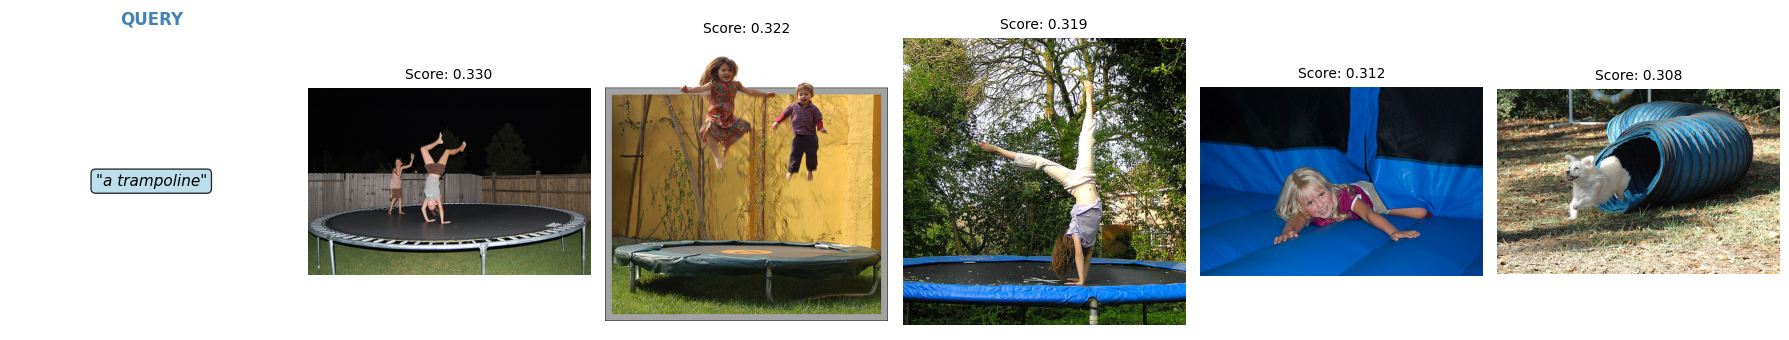

In [14]:
query = "a trampoline"

paths, scores = search_by_text(query)

show_results(query, paths, scores)

In [ ]:
# another examples
...
...

## 🧪 Next Steps & Extensions

A few directions to push this further:

### **🖼️ Image-to-image search**

`show_image_results` is already defined — wire up a sibling of `search_by_text`
that takes an image path, encodes it with `get_image_features`, and runs the
same dot-product lookup. That gives you a "more like this" feature for free.

### **🗺️ Embedding visualization**

We imported `umap-learn` for a reason: projecting the 512-dim image embeddings
down to 2D with UMAP gives a beautiful map of the dataset's semantic structure
— similar scenes cluster together.

### **🚀 Scaling up**

For datasets in the millions, swap the brute-force dot product for an ANN
index — **FAISS** (`IndexFlatIP` → `IndexHNSWFlat`) is the standard move and
keeps queries fast even at very large scale.

### **🎛️ Try a bigger CLIP**

`openai/clip-vit-large-patch14` (768-dim, ~430 M params) gives noticeably
better retrieval quality at the cost of slower encoding. For top-tier results,
look at **OpenCLIP** checkpoints trained on LAION.